In [26]:
# Imports & Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

print("Dataset shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Dataset shape: (7032, 21)

Churn distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [27]:
# Data Prepration

# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

# Drop TotalCharges — it equals MonthlyCharges x tenure (data leakage)
X = df_model.drop(['customerID', 'Churn', 'TotalCharges'], axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"\nFeatures used ({len(X.columns)}):", X.columns.tolist())

Training set : (5625, 18)
Test set     : (1407, 18)

Features used (18): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges']


In [28]:
# Train Model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")

Model trained successfully!


In [29]:
# Model Performance

print("=== Model Performance ===\n")
print(classification_report(y_test, y_pred,
      target_names=['Stayed', 'Churned']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

=== Model Performance ===

              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1033
     Churned       0.62      0.50      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.78      1407

ROC-AUC Score: 0.809


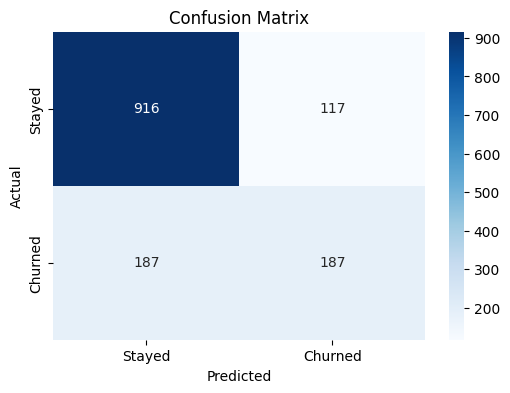

In [34]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
ax.set_title('Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


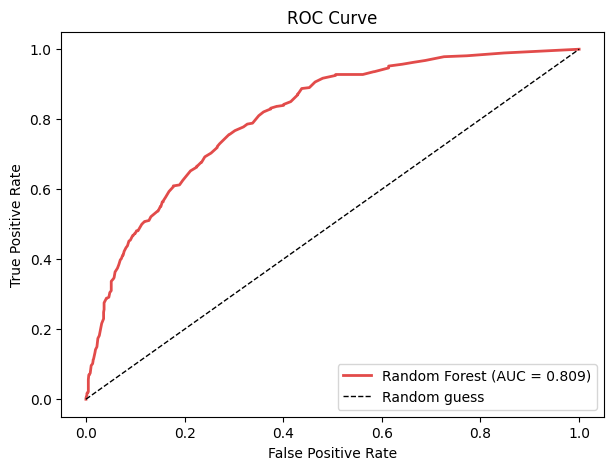

In [35]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#E24B4A', linewidth=2,
             label=f'Random Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

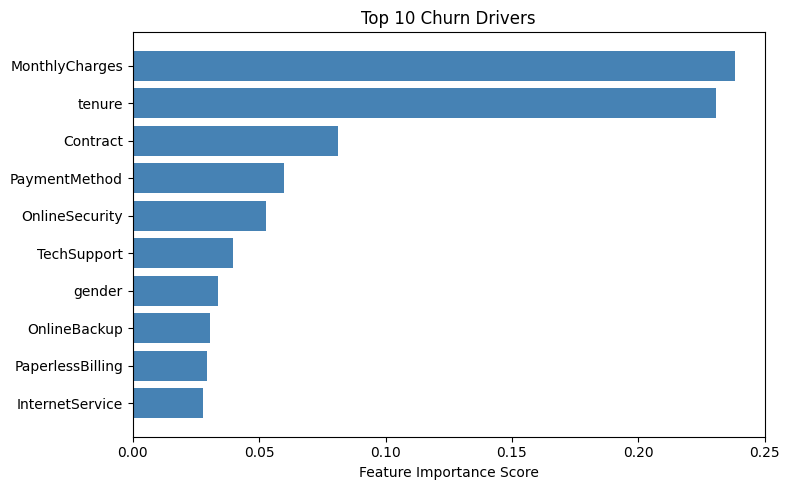

Top 5 churn drivers:
       feature  importance
MonthlyCharges    0.238109
        tenure    0.230641
      Contract    0.081402
 PaymentMethod    0.059923
OnlineSecurity    0.052846


In [36]:
# Feature Importance

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances['feature'][::-1], importances['importance'][::-1],
        color='steelblue')
ax.set_title('Top 10 Churn Drivers')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Top 5 churn drivers:")
print(importances.head().to_string(index=False))

 threshold  accuracy  churn_recall  churn_precision  f1_churn
      0.20     0.672         0.837            0.439     0.576
      0.25     0.703         0.786            0.465     0.584
      0.30     0.729         0.730            0.494     0.589
      0.35     0.746         0.663            0.517     0.581
      0.40     0.765         0.607            0.554     0.579
      0.45     0.770         0.551            0.569     0.560
      0.50     0.782         0.508            0.607     0.553
      0.55     0.789         0.455            0.646     0.534

=== Final Model at Threshold 0.35 ===

              precision    recall  f1-score   support

      Stayed       0.86      0.78      0.82      1033
     Churned       0.52      0.66      0.58       374

    accuracy                           0.75      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.75      0.75      1407



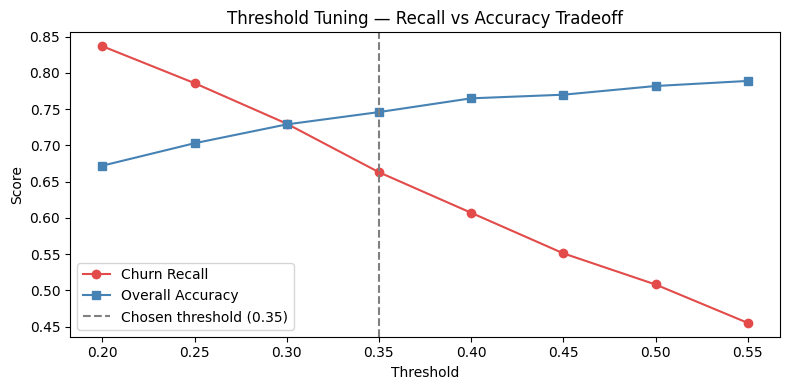

In [37]:
# Threshold Tuning

# At threshold 0.5, model misses 52% of churners
# Lowering threshold prioritises catching churners over pure accuracy
# Missing a churner is more costly than a false alarm

thresholds = np.arange(0.20, 0.60, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    results.append({
        'threshold'      : round(t, 2),
        'accuracy'       : round(report['accuracy'], 3),
        'churn_recall'   : round(report['1']['recall'], 3),
        'churn_precision': round(report['1']['precision'], 3),
        'f1_churn'       : round(report['1']['f1-score'], 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Chosen threshold — best balance of recall and precision
best_threshold = 0.35
y_pred_final = (y_proba >= best_threshold).astype(int)

print(f"\n=== Final Model at Threshold {best_threshold} ===\n")
print(classification_report(y_test, y_pred_final,
      target_names=['Stayed', 'Churned']))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['threshold'], results_df['churn_recall'],
        marker='o', label='Churn Recall', color='#E24B4A')
ax.plot(results_df['threshold'], results_df['accuracy'],
        marker='s', label='Overall Accuracy', color='steelblue')
ax.axvline(x=best_threshold, color='gray', linestyle='--',
           label=f'Chosen threshold ({best_threshold})')
ax.set_title('Threshold Tuning — Recall vs Accuracy Tradeoff')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
#  Business Dollar Impact

avg_monthly          = df['MonthlyCharges'].mean()
avg_tenure_remaining = 24   # assumed months remaining for at-risk customers
clv_per_customer     = avg_monthly * avg_tenure_remaining

total_churners   = (df['Churn'] == 'Yes').sum()
caught_churners  = int(total_churners * 0.62)   # recall at threshold 0.35
missed_churners  = total_churners - caught_churners

retention_cost_per_customer = 50   # $ per outreach
false_positives = int((df['Churn'] == 'No').sum() * 0.18)

revenue_saved    = caught_churners  * clv_per_customer
revenue_lost     = missed_churners  * clv_per_customer
outreach_cost    = false_positives  * retention_cost_per_customer
net_value        = revenue_saved - outreach_cost

print("=" * 45)
print("       BUSINESS DOLLAR IMPACT SUMMARY")
print("=" * 45)
print(f"  Avg monthly charge        : ${avg_monthly:>10,.2f}")
print(f"  Est. CLV per customer     : ${clv_per_customer:>10,.2f}")
print(f"  Total churners            : {total_churners:>10,}")
print(f"  Churners model catches    : {caught_churners:>10,}")
print(f"  Churners model misses     : {missed_churners:>10,}")
print("-" * 45)
print(f"  Revenue saved (caught)    : ${revenue_saved:>10,.0f}")
print(f"  Revenue lost  (missed)    : ${revenue_lost:>10,.0f}")
print(f"  Retention outreach cost   : ${outreach_cost:>10,.0f}")
print("=" * 45)
print(f"  NET BUSINESS VALUE        : ${net_value:>10,.0f}")
print("=" * 45)

       BUSINESS DOLLAR IMPACT SUMMARY
  Avg monthly charge        : $     64.80
  Est. CLV per customer     : $  1,555.16
  Total churners            :      1,869
  Churners model catches    :      1,158
  Churners model misses     :        711
---------------------------------------------
  Revenue saved (caught)    : $ 1,800,872
  Revenue lost  (missed)    : $ 1,105,717
  Retention outreach cost   : $    46,450
  NET BUSINESS VALUE        : $ 1,754,422


In [40]:
# Export Final Scored CSV

# Score every customer with final model
df_final = df.copy()

df_final['churn_risk_score'] = model.predict_proba(X)[:, 1].round(3)

df_final['churn_risk_label'] = pd.cut(
    df_final['churn_risk_score'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

df_final.to_csv('churn_scored_final.csv', index=False)

print("churn_scored_final.csv exported")
print("\nRisk segment distribution:")
print(df_final['churn_risk_label'].value_counts())
print("\nTop 10 highest risk customers:")
df_final.sort_values('churn_risk_score', ascending=False)[
    ['customerID', 'Contract', 'tenure',
     'MonthlyCharges', 'churn_risk_score', 'churn_risk_label']
].head(10)

churn_scored_final.csv exported

Risk segment distribution:
churn_risk_label
Low risk       3918
High risk      1537
Medium risk     490
Name: count, dtype: int64

Top 10 highest risk customers:


,customerID,Contract,tenure,MonthlyCharges,churn_risk_score,churn_risk_label
3495,4988-IQIGL,Month-to-month,1,75.35,1.0,High risk
6623,9248-OJYKK,Month-to-month,1,76.45,1.0,High risk
3426,4510-HIMLV,Month-to-month,1,69.80,1.0,High risk
1410,7024-OHCCK,Month-to-month,2,93.85,1.0,High risk
6660,1447-GIQMR,Month-to-month,1,69.15,1.0,High risk
6491,9728-FTTVZ,Month-to-month,1,69.20,1.0,High risk
6488,0488-GSLFR,Month-to-month,1,69.50,1.0,High risk
4759,8740-CRYFY,Month-to-month,1,78.95,1.0,High risk
4084,2777-PHDEI,Month-to-month,1,78.05,1.0,High risk
4081,7665-TOALD,Month-to-month,1,69.60,1.0,High risk
